In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

print("Libraries loaded successfully! 🚀")

c:\Users\aadia\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully! 🚀


In [5]:
# Adjust the filename if you want to use train.csv instead!
# Notice the 'r' right before the quotes!
df = pd.read_csv(r"C:\Users\aadia\OneDrive\Desktop\Sales Data\data\train.csv")

# If your date column is a string, convert it to actual datetime objects
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'])

# Display the top 5 rows (Jupyter will render this as a beautiful table)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [10]:
# Tell Python explicitly that the DAY comes first (DD/MM/YYYY)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Now group the data by day to get total daily sales
daily_sales = df.groupby(df['Order Date'].dt.date)['Sales'].sum().reset_index()

# Rename the columns to 'ds' and 'y' for Prophet
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

print(f"Data formatted! We have {len(daily_sales)} days of historical data.")
daily_sales.head()

Data formatted! We have 1230 days of historical data.


,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [11]:
# Initialize the Prophet model
m = Prophet(yearly_seasonality=True, daily_seasonality=False)

# Train the model on your data (The Heavy Lifting!)
m.fit(daily_sales)

print("Training Complete! The AI has learned your sales patterns. 🚀")

01:57:41 - cmdstanpy - INFO - Chain [1] start processing
01:57:41 - cmdstanpy - INFO - Chain [1] done processing


Training Complete! The AI has learned your sales patterns. 🚀


In [12]:
# Create a blank calendar for the next 30 days
future_dates = m.make_future_dataframe(periods=30)

# Ask the model to fill in the blanks with predictions
forecast = m.predict(future_dates)

# Show the predictions for the last 5 days of the future!
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1255,2019-01-25,1748.844356,-1063.511839,4420.635868
1256,2019-01-26,2213.026500,-751.121534,5024.068853
1257,2019-01-27,1999.085719,-450.544587,4576.878311
1258,2019-01-28,1905.922143,-981.834362,4559.262033
1259,2019-01-29,2265.853224,-530.781632,4817.417827


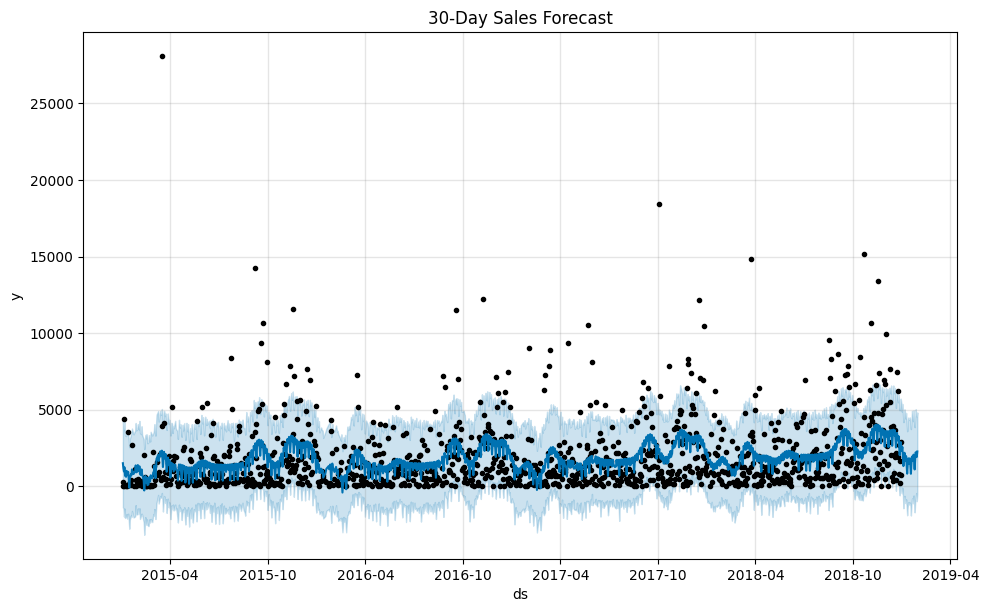

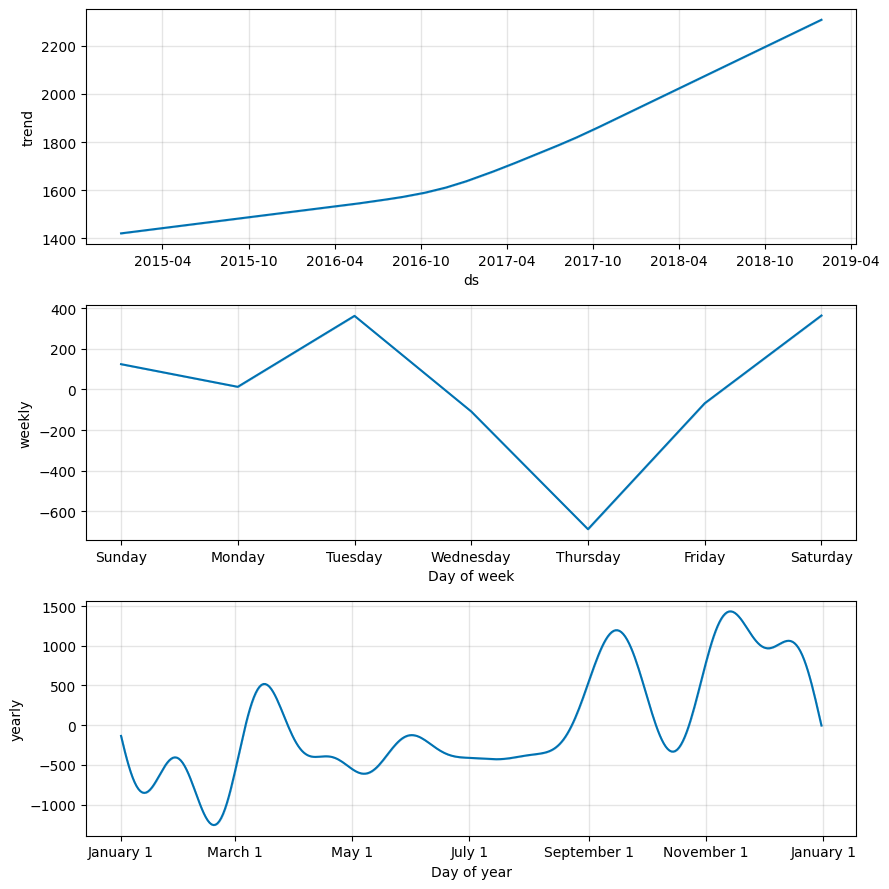

In [13]:
# Plot the main forecast timeline
fig1 = m.plot(forecast)
plt.title("30-Day Sales Forecast")
plt.show()

# Plot the individual trends (overall growth vs. weekly seasonality)
fig2 = m.plot_components(forecast)
plt.show()